# Prelim

In [2]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)
library(cowplot)

fig_size = function(width, heigth){
    options(repr.plot.width = width, repr.plot.height = heigth)
}

color_key = list(
    'human gwas' = 'lightpink1',
    'human eqtls' = 'firebrick1',
    'human coloc' = 'firebrick4',
    'pig gwas' = 'lightskyblue1',
    'pig eqtls' = 'royalblue1',
    'pig coloc' = 'navyblue',
    'cattle gwas' = 'mediumpurple1',
    'cattle eqtls' = 'purple',
    'cattle coloc' = 'purple4',
    'human' = 'firebrick1',
    'pig' = 'royalblue1',
    'cattle' = 'purple'
)

# Functions

Here are the files that are needed for any individual analysis:
- `*_enloc.sig.out`
- `*_glm_lead_snps.tsv`
- `*_pheno.sbams`
- `*_vars_scaling_*_maf_*.tsv`

In [3]:
# extract_gtex = function(enloc_name) {
#     # str_extract(enloc_name, 'gtex_scaling_[0-9]+_[^:]*tr[0-9]+') %>% str_replace('.*_', '')
#     str_replace(enloc_name, ':.*', '')
# }

# extract_gwas = function(enloc_name){
#     # gwas_names = str_extract_all(enloc_name, 'gwas_scaling_[0-9]+_[^:]*tr[0-9]+', simplify=T)
#     gwas_names = str_replace(enloc_name, '.*(@)', '')
#     gwas_names = unlist(gwas_names) %>% str_replace('.*_', '')
#     # gwas_names = apply(gwas_names, 2, unlist)
#     return(gwas_names)
# }

# extract_traits = function(df) {
#     df$gtex = sapply(df$Signal, function(x) extract_gtex(x), USE.NAMES=F)
#     df$gwas = sapply(df$Signal, function(x) extract_gwas(x), USE.NAMES=F)
#     return(df)
# }

extract_traits = function(df) {
    df %>% 
        separate_wider_delim(Signal, delim='(@)', names=c('gtex', 'gwas'), too_few='align_start', cols_remove=F) %>%
        filter(!is.na(gwas), gwas != '') %>%
        separate_longer_delim(gwas, delim='_') %>%
        mutate(gtex = str_replace(gtex, ':[0-9]+', ''), gwas = str_replace(gwas, ':[0-9]+', ''))
}

get_regex_file = function(ddir, pat) {
    # print(ddir)
    # print(pat)
    matching_file = list.files(path = ddir, pattern = pat)
    # print(matching_file)
    if (length(matching_file) > 1) {
        print('Error: too many matching files')
        return()
    } 
    if (length(matching_file) == 0) {
        print('Error: no matching file')
        return()
    }
    return(paste0(ddir, '/', matching_file[1]))
}

read_lead_snps = function(ddir, category) {
    ps = read.table(
        get_regex_file(ddir, paste0(category, '_glm_lead_snps.tsv')),
        col.names=c('file', 'chr', 'pos', 'id', 'ref', 'alt', 'provisional_ref', 'a1', 'omitted', 'a1_freq', 'test', 'obs_ct', 'beta', 'se', 't_stat', 'p', 'errcode'),
        sep='\t'
    ) %>%
    select(-provisional_ref, -omitted, -test, -obs_ct, -t_stat, -errcode) %>%
    mutate(
        category = gsub('_.*', '', file),
        trait = stringr::str_extract(file, 'tr[0-9]+'),
        trait_pos = as.numeric(gsub('tr', '', trait))
    )
    return(ps)
}

read_vars = function(ddir, var_type, m4=F) {
    # if (!(var_type %in% c('hgwas', 'hgtex', 'hgtex_smaller', 'hgtex_smallest', 'cgwas', 'cgtex', 'cgtex_smaller', 'cgtex_smallest'))) {
    if (!(var_type %in% c('gwas', 'gtex', 'gtex_smaller', 'gtex_smallest'))) {
        print('var_type must be one of gwas, gtex, gtex_smaller, gtex_smallest')
        return()
    }
    var_name = paste0(var_type, '_vars')
    vars = read.table(get_regex_file(ddir, var_name), header=T, as.is=T)
    if (var_type %in% c('gwas')) {
        vars = vars %>%
            mutate(gwas = paste0('tr', position), full_cat=var_type) %>% 
            select(gwas, time, daf, maf, selco, Vs, position, beta) %>% 
            rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs, gwas_beta = beta)
    } else if (var_type %in% c('gtex', 'gtex_smaller', 'gtex_smallest')) {
        vars = vars %>%
            mutate(gtex = paste0('tr', position), full_cat=var_type) %>% 
            select(gtex, time, daf, maf, selco, Vs, position, beta) %>% 
            rename(gtex_time = time, gtex_daf = daf, gtex_maf = maf, gtex_selco = selco, gtex_Vs = Vs, gtex_beta = beta)
    }

    # print(head(vars))
    if (m4) {
        m4_df = read_m4(ddir) %>% mutate(m4=1) %>% select(position, m4)
        vars = vars %>% left_join(m4_df)
    }

    return(vars)
}

read_enloc = function(ddir, gtex_category, add_m4=F) {
    # print(paste0(ddir, paste0(gtex_category, '.enloc.sig.out')))
    enloc = extract_traits(read.table(get_regex_file(ddir, paste0(gtex_category, '.enloc.sig.out')), header=T, as.is=T)) %>%
        unnest(cols=c(gwas), keep_empty=T)
    # print(head(enloc %>% select(-CPIP_qtl, -CPIP_gwas_marginal, -CPIP_gwas_qtl_prior), 2))
    enloc = enloc %>% 
        mutate(correct = !is.na(gwas) & gtex == gwas) %>%
        full_join(
            read_lead_snps(ddir, 'gwas') %>% rename(gwas = trait, min_snp_pos_gwas = pos, gwas_p = p) %>% select(gwas, min_snp_pos_gwas, gwas_p)
        ) %>% full_join(
            read_lead_snps(ddir, gtex_category) %>% rename(gtex = trait, min_snp_pos_gtex = pos, gtex_p = p) %>% select(gtex, min_snp_pos_gtex, gtex_p)
        ) %>% distinct() %>%
        left_join(., read_vars(ddir, gtex_category), by='gtex', copy=T) %>% 
        left_join(., read_vars(ddir, 'gwas', m4=add_m4), by='gwas')

    # br = -1*c(Inf, 2**seq(-7, -15), 0, -Inf)
    br = -1*c(Inf, 2**seq(-10, -15), 0, -Inf)
    maf_br = seq(0, 0.5, 0.05)
    enloc = enloc %>% mutate(
        selco_bin = cut(gwas_selco, breaks=br, right=F),
        maf_bin = cut(gwas_maf, breaks = maf_br),
        dist_true_gwas_gtex = abs(as.numeric(str_replace(gwas, 'tr', '')) - as.numeric(str_replace(gtex, 'tr', ''))),
        dist_lead_gwas_gtex = abs(min_snp_pos_gwas - min_snp_pos_gtex)
    )
    return(enloc)
}

read_traits = function(ddir, gtex_category) {
    gwas_traits = read.table(get_regex_file(ddir, 'gwas_scaling_35_pheno.sbams'))$V2
    gtex_traits = read.table(get_regex_file(ddir, paste0(gtex_category, '_scaling_35_pheno.sbams')))$V2
    traits = intersect(gwas_traits, gtex_traits)
    return(data.frame(trait=traits))
}

read_m4 = function(ddir) {
    m4 = read.table(get_regex_file(ddir, 'm4_marks.tsv'), header=T, as.is=T) %>% mutate(trait = paste0('tr', position))
    return(m4)
}

# Figure 2A

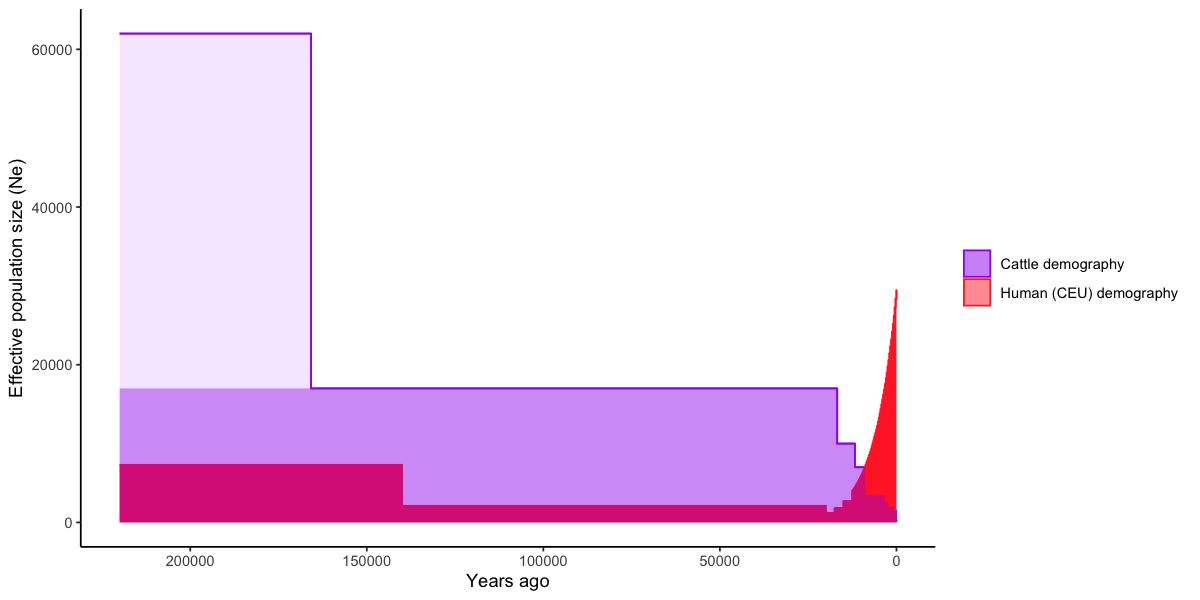

In [4]:
cattle_demo = data.frame(
    species = 'cattle',
    gen_ago = c(44000, 33154, 3354, 2354, 1754, 654, 454, 154, 24, 18, 12, 6, 3),
    Ne = c(6.2e4, 1.7e4, 1e4, 7e3, 3.5e3, 2.5e3, 2e3, 1.5e3, 1e3, 350, 250, 120, 90)
)
cattle_demo$years_ago = cattle_demo$gen_ago * 5

anc_pop = 7300
anc_gen_ago = 8800
ooa_pop = 2100
ooa_gen_ago = 5600
eu_as_gen_ago = 848
eu_as_pop = 1000
growth_rate = 0.004

human_ne = function(gen_ago) {
    if(gen_ago > ooa_gen_ago) {
        return(anc_pop)
    } else if (gen_ago <= ooa_gen_ago && gen_ago > eu_as_gen_ago) {
        return(ooa_pop)
    } else if (gen_ago <= eu_as_gen_ago) {
        return(eu_as_pop * (1+growth_rate)^(eu_as_gen_ago - gen_ago))
    }
}

human_demo = data.frame(
    species = 'human',
    gen_ago = c(seq(anc_gen_ago, 500, -100), seq(490, 0, -10))
)
human_demo$Ne = sapply(human_demo$gen_ago, human_ne)
human_demo$years_ago = human_demo$gen_ago * 25

demos = rbind(cattle_demo, human_demo)

# This is just a fast way to get the fill correct
shifted_cattle = cattle_demo[2:nrow(cattle_demo), c(1,4)]
shifted_cattle$years_ago = shifted_cattle$years_ago + 1
shifted_cattle$Ne = cattle_demo$Ne[1:(nrow(cattle_demo)-1)]

shifted_human = human_demo[2:nrow(human_demo), c(1,4)]
shifted_human$years_ago = shifted_human$years_ago + 1
shifted_human$Ne = human_demo$Ne[1:(nrow(human_demo)-1)]

boxes = rbind(
    demos %>% select(species, years_ago, Ne),
    shifted_cattle,
    shifted_human
)

fig_size(10,5)

# I have have this double plotted stuff to make part of the box paler
boxes = boxes %>% mutate(alp = ifelse(species=='cattle', 0.2, 0.5))
boxes2 = boxes %>% filter(species=='cattle') %>% mutate(Ne = ifelse(Ne == 62000, 17000, Ne), alp = 0.3)

boxes %>%
arrange(species, desc(years_ago)) %>%
ggplot(aes(x=years_ago, y=Ne, color=species, fill=species)) + 
    scale_x_reverse() + geom_step(show.legend=F) + theme_classic() +
    xlab('Years ago') + ylab('Effective population size (Ne)') + theme(legend.title=element_blank()) +
    geom_area(position='identity', aes(alpha=alp)) +
    geom_area(data=boxes2, aes(x=years_ago, y=Ne, alpha=alp), color=NA, fill=color_key[['cattle']], show.legend=F) + 
    scale_color_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_fill_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_alpha(guide='none') +
    guides(fill = guide_legend(override.aes = list(alpha = 0.5)))

# Test

In [5]:
get_dfs = function(sim_category, ddir_base = '/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb', replicates=10) {
    # I know this could be better done with loops, but I was just copying and pasting from my earlier steps. Life goes on.
    # ddir1 = sprintf('%s/%s/%s1', ddir_base, sim_category, sim_category)
    # ddir2 = sprintf('%s/%s/%s2', ddir_base, sim_category, sim_category)
    # ddir3 = sprintf('%s/%s/%s3', ddir_base, sim_category, sim_category)
    # ddir4 = sprintf('%s/%s/%s4', ddir_base, sim_category, sim_category)

    if (sim_category %in% c('A', 'B', 'C', 'D')) sim_species = 'human'
    if (sim_category %in% c('E', 'F', 'G')) sim_species = 'cattle'
    pos_sel = sim_category %in% c('F', 'G')

    br = -1*c(Inf, 2**seq(-10, -15), 0, -Inf)
    maf_br = seq(0, 0.5, 0.05)

    list_enloc = list()
    list_trait = list()
    list_leads = list()
    list_vars = list()
    for (i in 1:replicates) {
        ddir = sprintf('%s/%s/%s%s', ddir_base, sim_category, sim_category, i)
        list_enloc[[i]] = rbind(
            read_enloc(ddir, gtex_category='gtex', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), gtex_category = 'gtex'),
            read_enloc(ddir, gtex_category='gtex_smaller', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), gtex_category = 'gtex_smaller')#,
            # read_enloc(ddir, gtex_category='gtex_smallest', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), gtex_category = 'gtex_smallest')
        ) %>% mutate(species = sim_species)

        list_trait[[i]] = rbind(
            read_traits(ddir, gtex_category='gwas') %>% mutate(sim=paste0(sim_category, str(i)), type='gwas'),
            read_traits(ddir, gtex_category='gtex') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex'),
            read_traits(ddir, gtex_category='gtex_smaller') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smaller')#,
            # read_traits(ddir, gtex_category='gtex_smallest') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smallest')
        ) %>% mutate(species = sim_species)

        list_leads[[i]] = rbind(
            read_lead_snps(ddir, category='gwas') %>% mutate(sim=paste0(sim_category, str(i)), type='gwas') %>% select(-file, -category),
            read_lead_snps(ddir, category='gtex') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex') %>% select(-file, -category),
            read_lead_snps(ddir, category='gtex_smaller') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smaller') %>% select(-file, -category)# ,
            # read_lead_snps(ddir, category='gtex_smallest') %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smallest') %>% select(-file, -category)
        ) %>% mutate(species = sim_species)

        list_vars[[i]] = rbind(
            read_vars(ddir, 'gwas', m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), type='gwas') %>% 
                rename_with(~ str_remove(.x, 'gwas_')) %>% rename(trait=gwas) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gwas'),
            read_vars(ddir, 'gtex', m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), type='gtex') %>% rename_with(~ str_remove(.x, 'gtex_')) %>% 
                rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex'),
            read_vars(ddir, 'gtex_smaller', m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smaller') %>% 
                rename_with(~ str_remove(.x, 'gtex_')) %>% rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex_smaller')# ,
            # read_vars(ddir, 'gtex_smallest', m4=pos_sel) %>% mutate(sim=paste0(sim_category, str(i)), type='gtex_smallest')  %>% rename_with(~ str_remove(.x, 'gtex_')) %>%
            #     rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex_smallest')
        ) %>% mutate(species = sim_species)
    }

    tmp_enloc = do.call(rbind, list_enloc)
    tmp_traits = do.call(rbind, list_trait)
    tmp_leads = do.call(rbind, list_leads)
    tmp_vars = do.call(rbind, list_vars)

    return(list(enloc=tmp_enloc, traits=tmp_traits, leads=tmp_leads, vars=tmp_vars))

    # tmp_enloc = rbind(
    #     read_enloc(ddir1, human=F, gtex_category='gtex', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '1'), gtex_category = 'gtex'),
    #     read_enloc(ddir2, human=F, gtex_category='gtex', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '2'), gtex_category = 'gtex'),
    #     read_enloc(ddir3, human=F, gtex_category='gtex', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '3'), gtex_category = 'gtex'),
    #     read_enloc(ddir4, human=F, gtex_category='gtex', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '4'), gtex_category = 'gtex'),
    #     read_enloc(ddir1, human=F, gtex_category='gtex_smaller', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '1'), gtex_category = 'gtex_smaller'),
    #     read_enloc(ddir2, human=F, gtex_category='gtex_smaller', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '2'), gtex_category = 'gtex_smaller'),
    #     read_enloc(ddir3, human=F, gtex_category='gtex_smaller', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '3'), gtex_category = 'gtex_smaller'),
    #     read_enloc(ddir4, human=F, gtex_category='gtex_smaller', add_m4=pos_sel) %>% mutate(sim=paste0(sim_category, '4'), gtex_category = 'gtex_smaller')#,
    #     # read_enloc(ddir1, human=F, gtex_category='gtex_smallest', add_m4=pos_sel) %>% mutate(sim='e1', gtex_category = 'gtex_smallest'),
    #     # read_enloc(ddir2, human=F, gtex_category='gtex_smallest', add_m4=pos_sel) %>% mutate(sim='e2', gtex_category = 'gtex_smallest'),
    #     # read_enloc(ddir3, human=F, gtex_category='gtex_smallest', add_m4=pos_sel) %>% mutate(sim='e3', gtex_category = 'gtex_smallest'),
    #     # read_enloc(ddir4, human=F, gtex_category='gtex_smallest', add_m4=pos_sel) %>% mutate(sim='e4', gtex_category = 'gtex_smallest')
    # ) %>% mutate(species = sim_species)

    # tmp_traits = rbind(
    #     read_traits(ddir1, gtex_category='gwas') %>% mutate(sim=paste0(sim_category, '1'), type='gwas'),
    #     read_traits(ddir2, gtex_category='gwas') %>% mutate(sim=paste0(sim_category, '2'), type='gwas'),
    #     read_traits(ddir3, gtex_category='gwas') %>% mutate(sim=paste0(sim_category, '3'), type='gwas'),
    #     read_traits(ddir4, gtex_category='gwas') %>% mutate(sim=paste0(sim_category, '4'), type='gwas'),
    #     read_traits(ddir1, gtex_category='gtex') %>% mutate(sim=paste0(sim_category, '1'), type='gtex'),
    #     read_traits(ddir2, gtex_category='gtex') %>% mutate(sim=paste0(sim_category, '2'), type='gtex'),
    #     read_traits(ddir3, gtex_category='gtex') %>% mutate(sim=paste0(sim_category, '3'), type='gtex'),
    #     read_traits(ddir4, gtex_category='gtex') %>% mutate(sim=paste0(sim_category, '4'), type='gtex'),
    #     read_traits(ddir1, gtex_category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '1'), type='gtex_smaller'),
    #     read_traits(ddir2, gtex_category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '2'), type='gtex_smaller'),
    #     read_traits(ddir3, gtex_category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '3'), type='gtex_smaller'),
    #     read_traits(ddir4, gtex_category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '4'), type='gtex_smaller')#,
    #     # read_traits(ddir1, gtex_category='gtex_smallest') %>% mutate(sim='e1', type='gtex_smallest'),
    #     # read_traits(ddir2, gtex_category='gtex_smallest') %>% mutate(sim='e2', type='gtex_smallest'),
    #     # read_traits(ddir3, gtex_category='gtex_smallest') %>% mutate(sim='e3', type='gtex_smallest'),
    #     # read_traits(ddir4, gtex_category='gtex_smallest') %>% mutate(sim='e4', type='gtex_smallest')
    # ) %>% mutate(species = sim_species)

    # tmp_leads =  rbind(
    #     read_lead_snps(ddir1, category='gwas') %>% mutate(sim=paste0(sim_category, '1'), type='gwas') %>% select(-file, -category),
    #     read_lead_snps(ddir2, category='gwas') %>% mutate(sim=paste0(sim_category, '2'), type='gwas') %>% select(-file, -category),
    #     read_lead_snps(ddir3, category='gwas') %>% mutate(sim=paste0(sim_category, '3'), type='gwas') %>% select(-file, -category),
    #     read_lead_snps(ddir4, category='gwas') %>% mutate(sim=paste0(sim_category, '4'), type='gwas') %>% select(-file, -category),
    #     read_lead_snps(ddir1, category='gtex') %>% mutate(sim=paste0(sim_category, '1'), type='gtex') %>% select(-file, -category),
    #     read_lead_snps(ddir2, category='gtex') %>% mutate(sim=paste0(sim_category, '2'), type='gtex') %>% select(-file, -category),
    #     read_lead_snps(ddir3, category='gtex') %>% mutate(sim=paste0(sim_category, '3'), type='gtex') %>% select(-file, -category),
    #     read_lead_snps(ddir4, category='gtex') %>% mutate(sim=paste0(sim_category, '4'), type='gtex') %>% select(-file, -category),
    #     read_lead_snps(ddir1, category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '1'), type='gtex_smaller') %>% select(-file, -category),
    #     read_lead_snps(ddir2, category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '2'), type='gtex_smaller') %>% select(-file, -category),
    #     read_lead_snps(ddir3, category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '3'), type='gtex_smaller') %>% select(-file, -category),
    #     read_lead_snps(ddir4, category='gtex_smaller') %>% mutate(sim=paste0(sim_category, '4'), type='gtex_smaller') %>% select(-file, -category)#,
    #     # read_lead_snps(ddir1, category='gtex_smallest') %>% mutate(sim='e1', type='gtex_smallest') %>% select(-file, -category),
    #     # read_lead_snps(ddir2, category='gtex_smallest') %>% mutate(sim='e2', type='gtex_smallest') %>% select(-file, -category),
    #     # read_lead_snps(ddir3, category='gtex_smallest') %>% mutate(sim='e3', type='gtex_smallest') %>% select(-file, -category),
    #     # read_lead_snps(ddir4, category='gtex_smallest') %>% mutate(sim='e4', type='gtex_smallest') %>% select(-file, -category)
    # ) %>% mutate(species = sim_species)

    # br = -1*c(Inf, 2**seq(-10, -15), 0, -Inf)
    # maf_br = seq(0, 0.5, 0.05)

    # tmp_vars = rbind(
    #     rbind(
    #         read_vars(ddir1, 'gwas', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '1'), type='gwas'),
    #         read_vars(ddir2, 'gwas', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '2'), type='gwas'),
    #         read_vars(ddir3, 'gwas', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '3'), type='gwas'),
    #         read_vars(ddir4, 'gwas', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '4'), type='gwas')
    #     ) %>% rename_with(~ str_remove(.x, 'gwas_')) %>% rename(trait=gwas) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gwas'),
    #     rbind(
    #         read_vars(ddir1, 'gtex', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '1'), type='gtex'),
    #         read_vars(ddir2, 'gtex', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '2'), type='gtex'),
    #         read_vars(ddir3, 'gtex', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '3'), type='gtex'),
    #         read_vars(ddir4, 'gtex', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '4'), type='gtex')
    #     ) %>% rename_with(~ str_remove(.x, 'gtex_')) %>% rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex'),
    #     rbind(
    #         read_vars(ddir1, 'gtex_smaller', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '1'), type='gtex_smaller'),
    #         read_vars(ddir2, 'gtex_smaller', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '2'), type='gtex_smaller'),
    #         read_vars(ddir3, 'gtex_smaller', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '3'), type='gtex_smaller'),
    #         read_vars(ddir4, 'gtex_smaller', m4=pos_sel) %>% mutate(sim=paste0(sim_category, '4'), type='gtex_smaller')
    #     ) %>% rename_with(~ str_remove(.x, 'gtex_')) %>% rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex_smaller')# ,
    #     # rbind(
    #     #     read_vars(ddir1, 'gtex_smallest', m4=pos_sel),
    #     #     read_vars(ddir2, 'gtex_smallest', m4=pos_sel),
    #     #     read_vars(ddir3, 'gtex_smallest', m4=pos_sel),
    #     #     read_vars(ddir4, 'gtex_smallest', m4=pos_sel)
    #     # ) %>% rename_with(~ str_remove(.x, 'gtex_')) %>% rename(trait=gtex) %>% mutate(selco_bin = cut(selco, breaks=br, right=F), maf_bin = cut(maf, breaks = maf_br), type='gtex_smallest')
    # ) %>% mutate(species = sim_species)
    
    # return(list(enloc=tmp_enloc, traits=tmp_traits, leads=tmp_leads, vars=tmp_vars))
}

In [6]:
plot_enloc_outcomes = function(dfs, gtex_cat='gtex', rcp_cutoff=0.5, p_cutoff=1, m4=F, rtrn=F, prnt=T) {
    tmp = dfs$enloc %>% filter(gtex_category == gtex_cat) %>% 
        arrange(desc(is.na(correct)), desc(correct), desc(is.na(RCP)), desc(RCP)) %>% 
        group_by(gwas, sim) %>%
        slice(1) %>%
        ungroup() %>% 
        mutate(RCP = ifelse(is.na(RCP), 0, RCP)) %>%
        mutate(outcome = ifelse(is.na(correct), 'Underpowered fine-mapping', ifelse(RCP <= rcp_cutoff, 'Underpowered colocalization', ifelse(correct, 'True positive', 'False positive')))) %>% 
        filter(!is.na(maf_bin), gwas_p < p_cutoff)

    tot = length(unique(paste(tmp$gwas, tmp$sim)))
    print(tot)
    tmp %>%
        summarize(tp = sum(outcome == 'True positive'), fp = sum(outcome == 'False positive'), ufm = sum(outcome == 'Underpowered fine-mapping'), uc = sum(outcome == 'Underpowered colocalization')) %>% print()
        # summarize(tp = sum(outcome == 'True positive')/tot, fp = sum(outcome == 'False positive')/tot, ufm = sum(outcome == 'Underpowered fine-mapping')/tot, uc = sum(outcome == 'Underpowered colocalization')/tot)

    p1 = tmp %>%
        ggplot(aes(x=maf_bin, fill=outcome)) + geom_bar(stat='count') + theme_classic() # + ylim(0, 250)

    if (m4) {
        tmp2 = tmp %>% filter(!is.na(m4) & m4 == 1)
        print(nrow(tmp2))
        tmp2 %>%
            summarize(tp = sum(outcome == 'True positive'), fp = sum(outcome == 'False positive'), ufm = sum(outcome == 'Underpowered fine-mapping'), uc = sum(outcome == 'Underpowered colocalization')) %>% print()
        p2 = tmp2 %>%
            ggplot(aes(x=maf_bin, fill=outcome)) + geom_bar(stat='count') + theme_classic() # + ylim(0, 250)
    }

    if (prnt) {
        # print(p1)
        if (m4) {
            fig_size(14, 5)
            print(cowplot(p1, p2, align='v', labels='AUTO'))
        } else{
            fig_size(7, 5)
            print(p1)
        }
    }
    if (rtrn) return(list(p1, p2))
}

# Set 1: 35x

In [50]:
simE = get_dfs('E')

Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`


 int 1


Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`


 int 1
 int 1
 int 1
 int 1
 int 1
 int 1
 int 1
 int 1
 int 1
 int 1


Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`


...

 int 9
 int 9
 int 9
 int 9
 int 9
 int 9
 int 9
 int 9
 int 9
 int 9


Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`


 int 10


Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`


 int 10
 int 10
 int 10
 int 10
 int 10
 int 10
 int 10
 int 10
 int 10
 int 10


In [23]:
list.files(path = "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_75_2Mb/A/A1/", pattern = 'gtex')

character(0)

In [31]:
simA = get_dfs('A')

[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gtex.enloc.sig.out"
[1] "human.hgtex.enloc.sig.out"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gwas_glm_lead_snps.tsv"
[1] "hgwas_glm_lead_snps.tsv"


Joining with `by = join_by(gwas)`


[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gtex_glm_lead_snps.tsv"
[1] "hgtex_glm_lead_snps.tsv"


Joining with `by = join_by(gtex)`


[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gtex_vars"
[1] "hgtex_vars_gwas_35_gtex_35_maf_0.01.tsv"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gwas_vars"
[1] "hgwas_vars_gwas_35_gtex_35_maf_0.01.tsv"
 int 1
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gtex_smaller.enloc.sig.out"
[1] "human.hgtex_smaller.enloc.sig.out"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A1"
[1] "gwas_glm_lead_snps.tsv"
[1] "hgwas_glm_lead_snps.tsv"


...

[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gtex_vars"
[1] "hgtex_vars_gwas_35_gtex_35_maf_0.01.tsv"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_vars"
[1] "hgwas_vars_gwas_35_gtex_35_maf_0.01.tsv"
 int 10
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gtex_smaller.enloc.sig.out"
[1] "human.hgtex_smaller.enloc.sig.out"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_glm_lead_snps.tsv"
[1] "hgwas_glm_lead_snps.tsv"


Joining with `by = join_by(gwas)`


[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gtex_smaller_glm_lead_snps.tsv"
[1] "hgtex_smaller_glm_lead_snps.tsv"


Joining with `by = join_by(gtex)`


[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gtex_smaller_vars"
[1] "hgtex_smaller_vars_gwas_35_gtex_35_maf_0.01.tsv"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_vars"
[1] "hgwas_vars_gwas_35_gtex_35_maf_0.01.tsv"
 int 10
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_scaling_35_pheno.sbams"
[1] "hgwas_scaling_35_pheno.sbams"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_scaling_35_pheno.sbams"
[1] "hgwas_scaling_35_pheno.sbams"
 int 10
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gwas_scaling_35_pheno.sbams"
[1] "hgwas_scaling_35_pheno.sbams"
[1] "/Users/noah/colocalization_humans_cattle_pigs/simulation_data/r2_25_2Mb/A/A10"
[1] "gtex_scaling_35_pheno.sbams"
[1] "hgtex_scaling_35_pheno.sbams"
 int 10
[1] "/Users/noah/colocalization_humans_cattle_pigs/simul

In [64]:
simB = get_dfs('B')

[1] "Error: no matching file"


ERROR: Error in read.table(get_regex_file(ddir, paste0(gtex_category, ".enloc.sig.out")), : 'file' must be a character string or connection


In [507]:
simF = get_dfs('F')

Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(position)`
Joining with `by = join_by(gwas)`
Joining with `by = join_by(gtex)`
Joining with `by = join_by(position)`
Joining with `by = join_by(pos

In [34]:
plot_selco_af = function(dfs, rtrn=F, prnt=T, min_maf=0) {
    tmp = dfs$vars %>% filter(maf >= min_maf, type == 'gwas') %>% select(trait, selco, maf, maf_bin, selco_bin, daf) %>% distinct()
    
    p1 = tmp %>%
    ggplot(aes(x=selco_bin, y=maf)) + geom_boxplot() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1))

    p2 = tmp %>% 
    ggplot(aes(x=maf)) + geom_histogram() + theme_classic() + ggtitle('Distribution of all allele frequencies')

    p3 = tmp %>% filter(selco == 0) %>%
    ggplot(aes(x=maf)) + geom_histogram() + theme_classic() + ggtitle('Distribution of neutral allele frequencies')

    p4 = tmp %>% filter(selco != 0) %>%
    ggplot(aes(x=maf)) + geom_histogram() + theme_classic() + ggtitle('Distribution of non-neutral allele frequencies')

    fig_size(12,10)
    if (prnt) {
        print(plot_grid(p1, p2, p3, p4, labels='AUTO', align='vh', ncol=2))
        # print(p1)
        # print(p2)
        # print(p3)
        # print(p4)
    }
    if (rtrn) return(list(p1, p2, p3, p4))
}

In [33]:
simA$vars %>% head()

,trait,time,daf,maf,selco,Vs,position,beta,selco_bin,maf_bin,type,species
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>,<chr>
1,tr10,9.407425,0.00003125,0.00003125,0,0,10,0,"[0, Inf)","(0,0.05]",gwas,human
2,tr12,11.380819,0.00003125,0.00003125,0,0,12,0,"[0, Inf)","(0,0.05]",gwas,human
3,tr18,5.626127,0.00003125,0.00003125,0,0,18,0,"[0, Inf)","(0,0.05]",gwas,human
4,tr32,2824.911894,0.00003125,0.00003125,0,0,32,0,"[0, Inf)","(0,0.05]",gwas,human
5,tr45,86.166137,0.00003125,0.00003125,0,0,45,0,"[0, Inf)","(0,0.05]",gwas,human
6,tr52,94.300749,0.00034375,0.00034375,0,0,52,0,"[0, Inf)","(0,0.05]",gwas,human


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


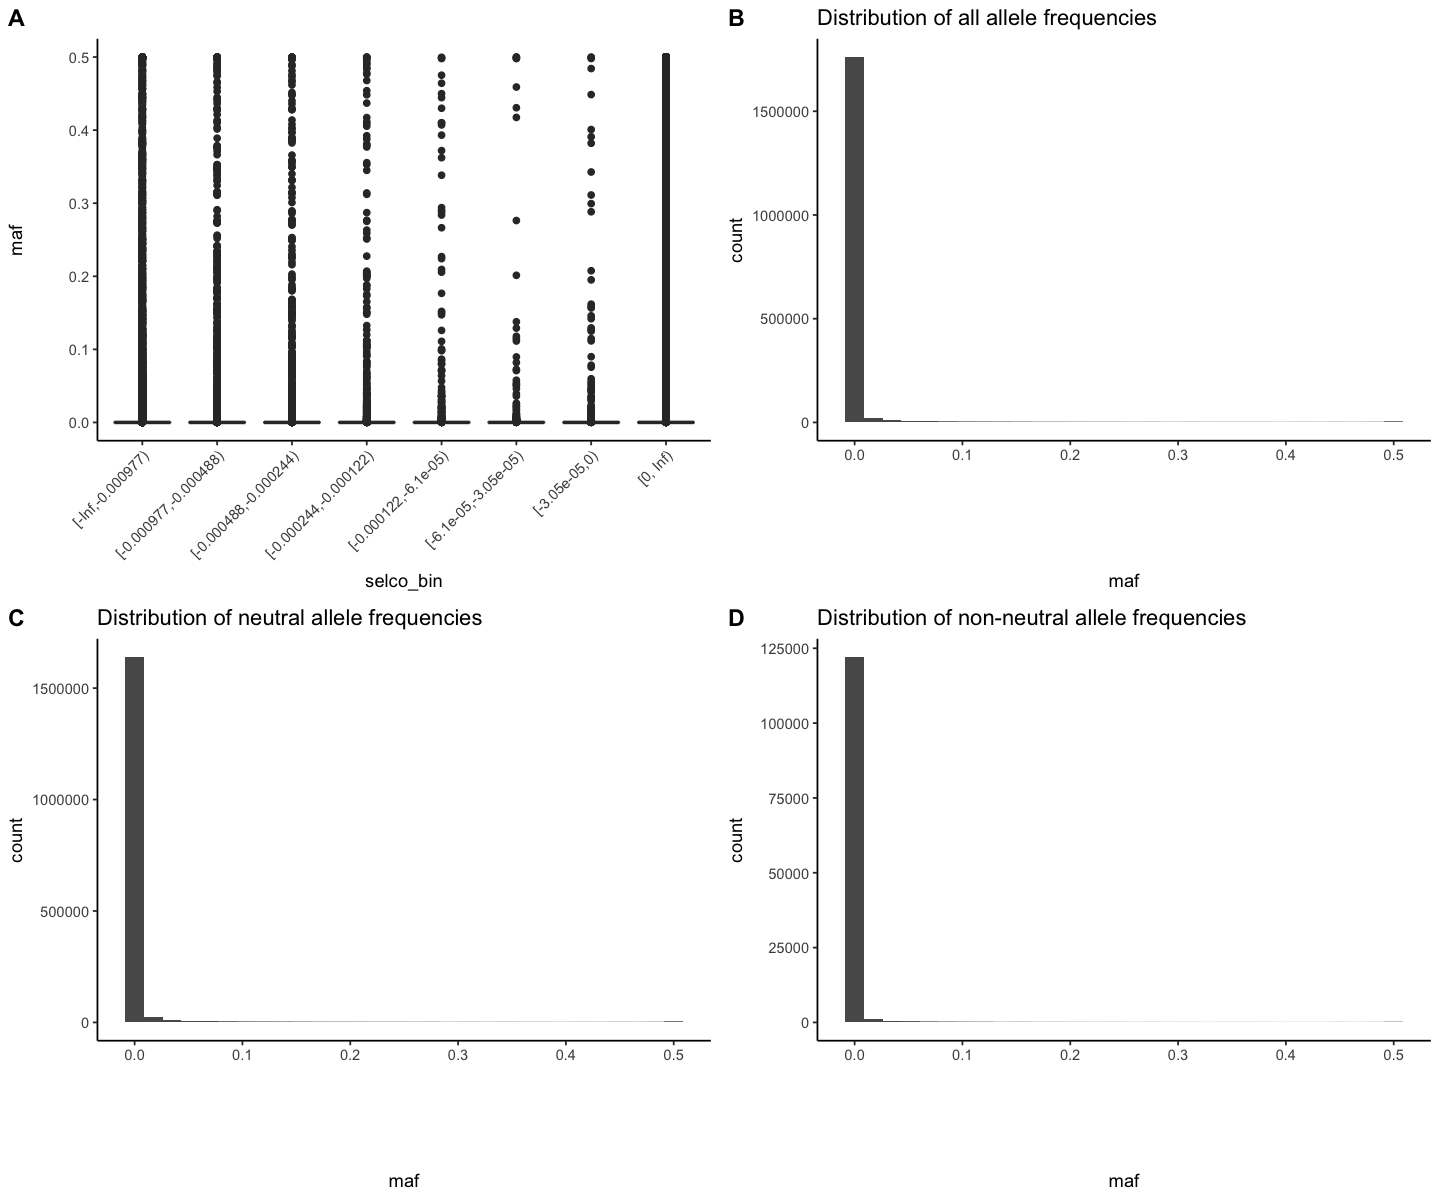

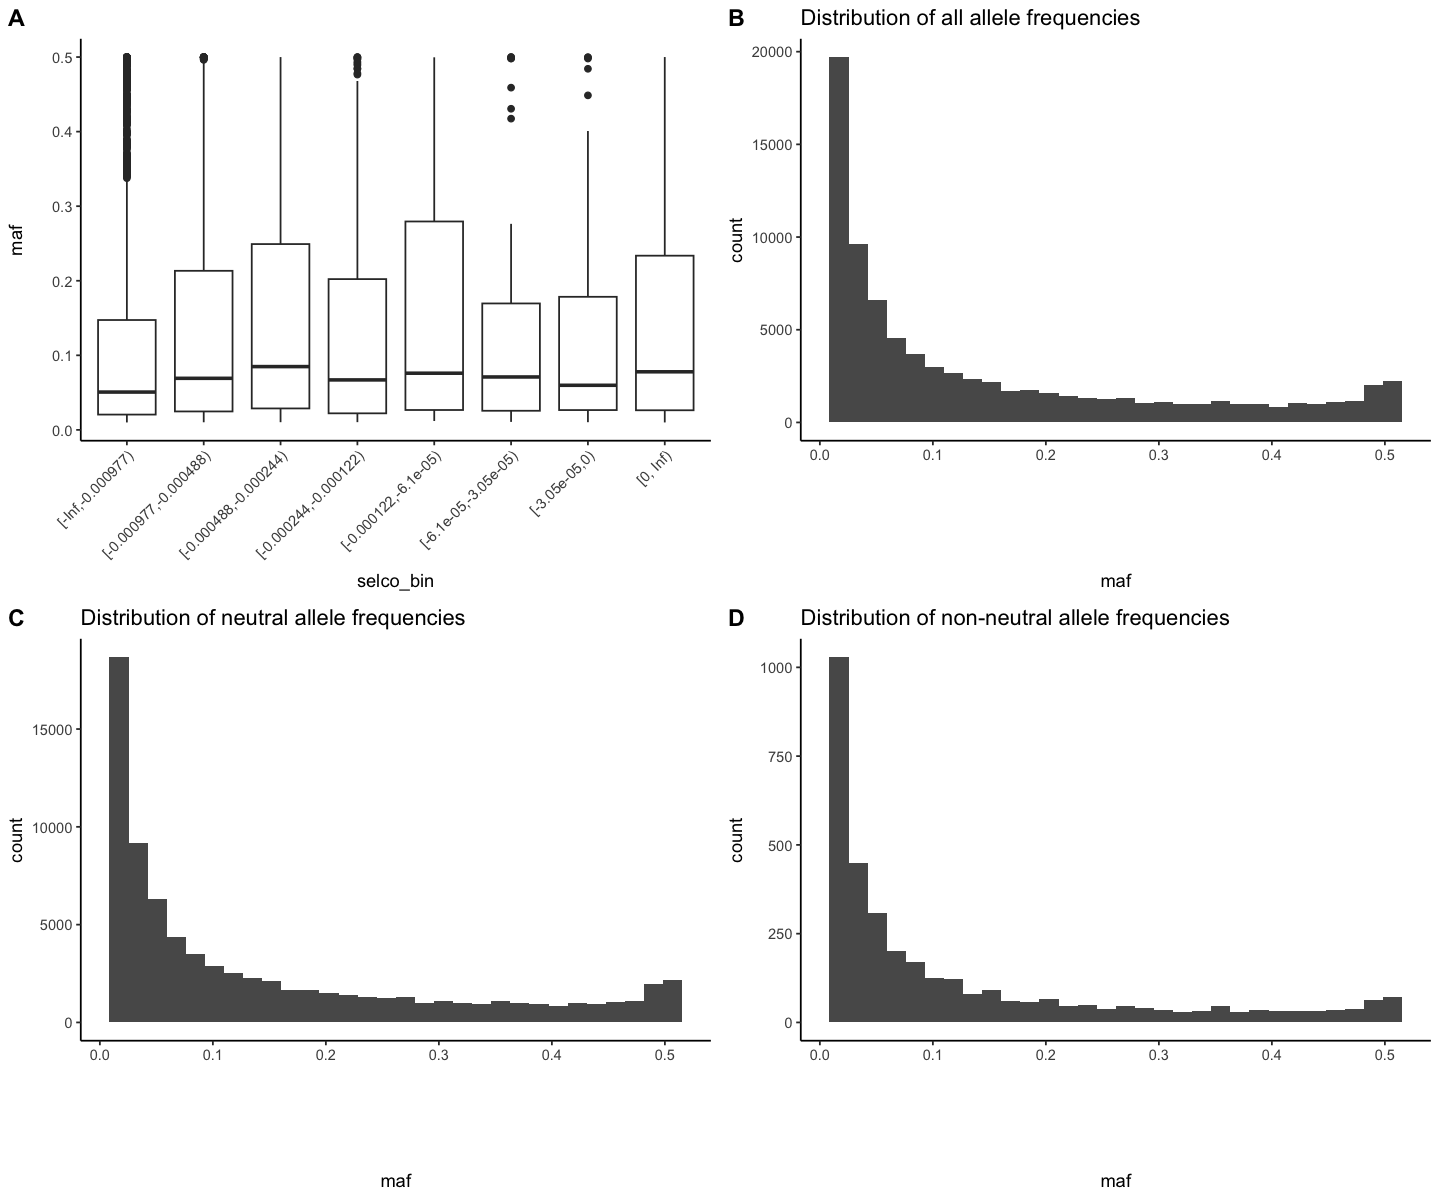

In [37]:
plot_selco_af(simA)
plot_selco_af(simA, min_maf = 0.01)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


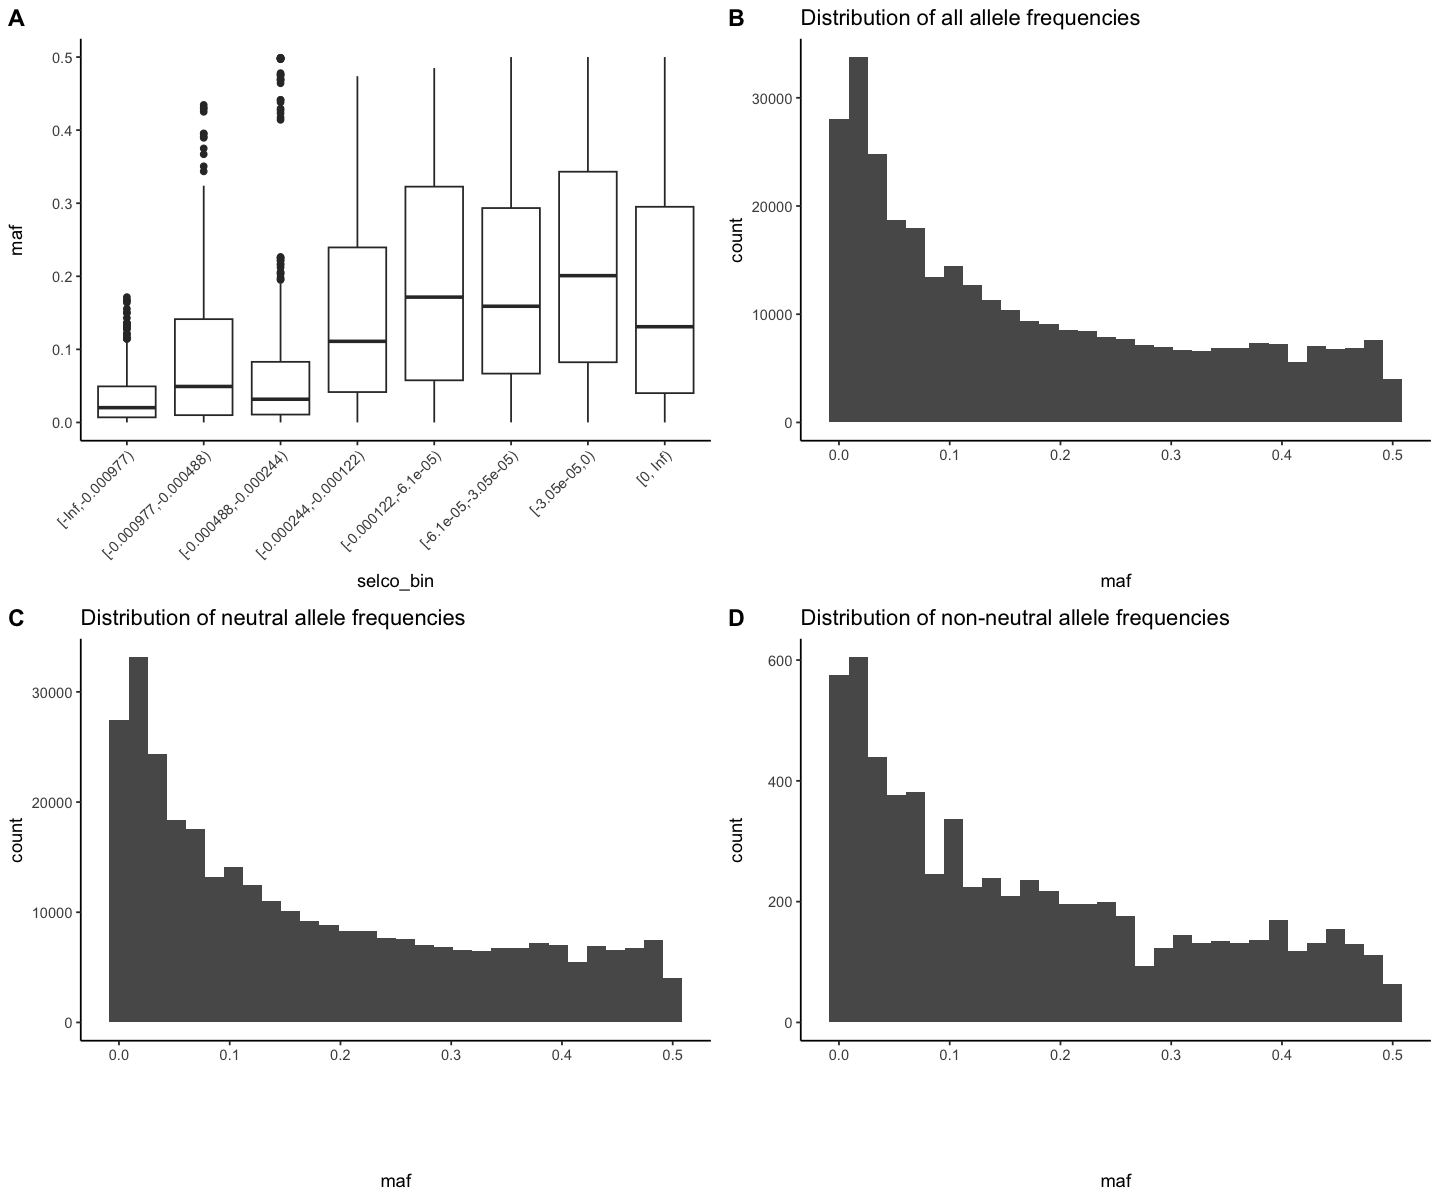

In [19]:
plot_selco_af(simE)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


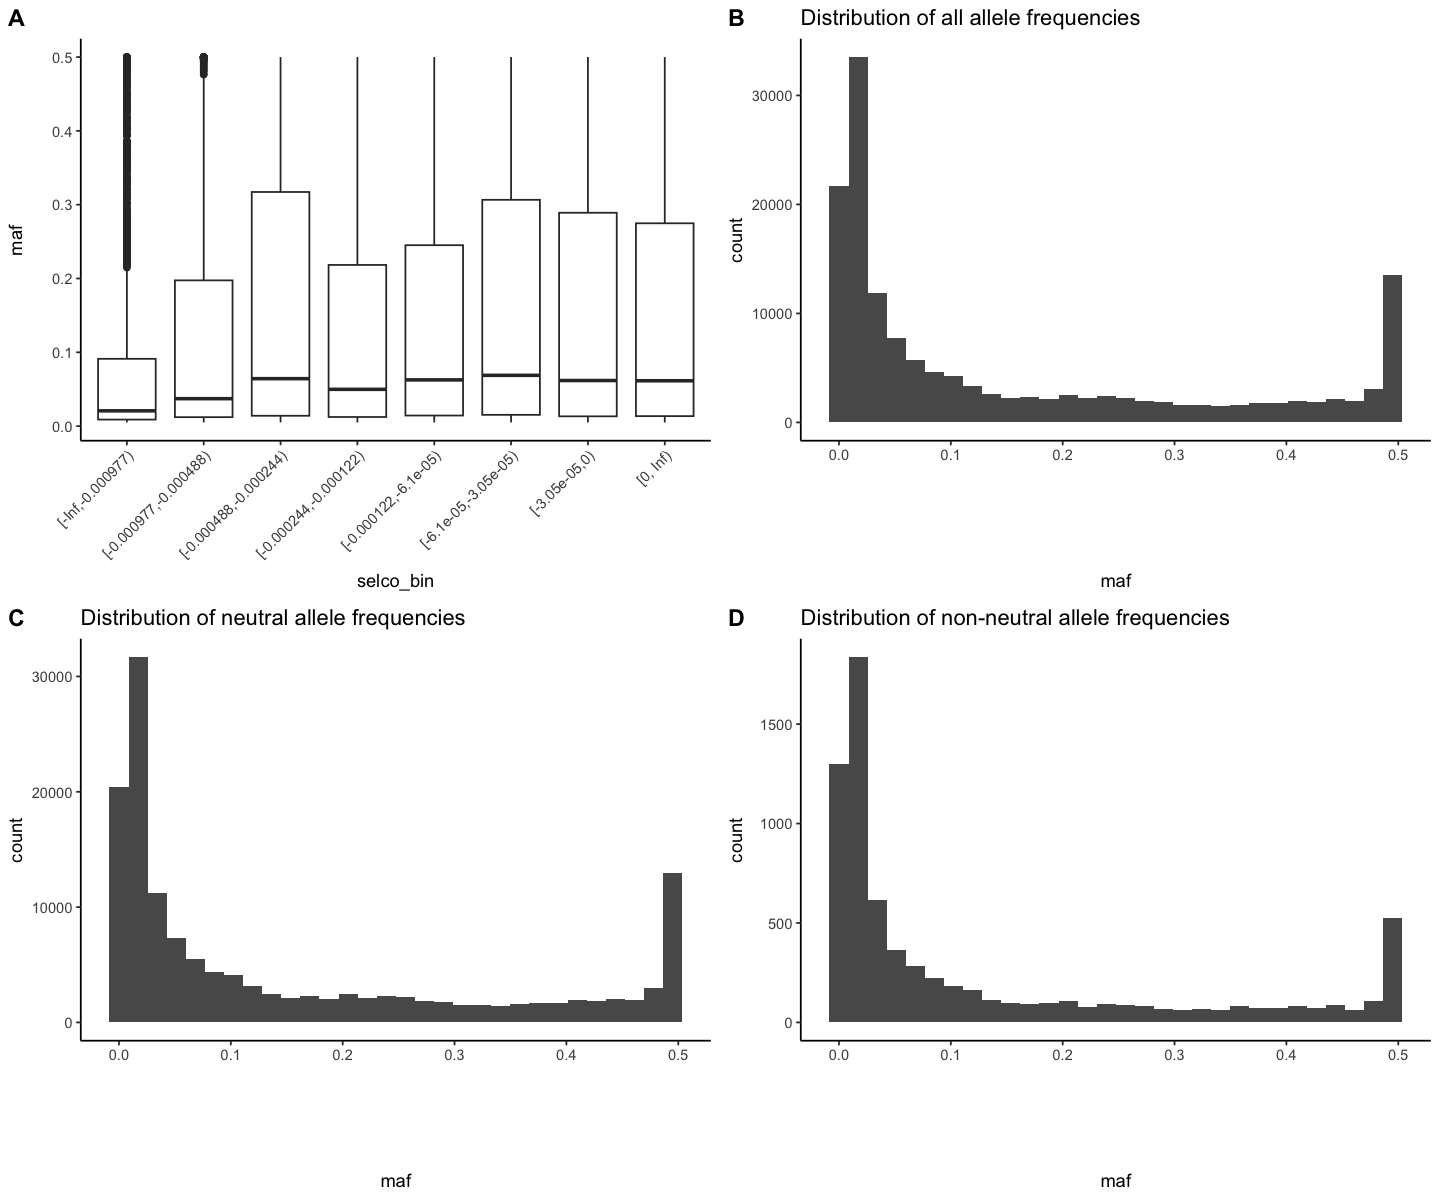

In [37]:
plot_selco_af(simA, min_maf=0.005)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


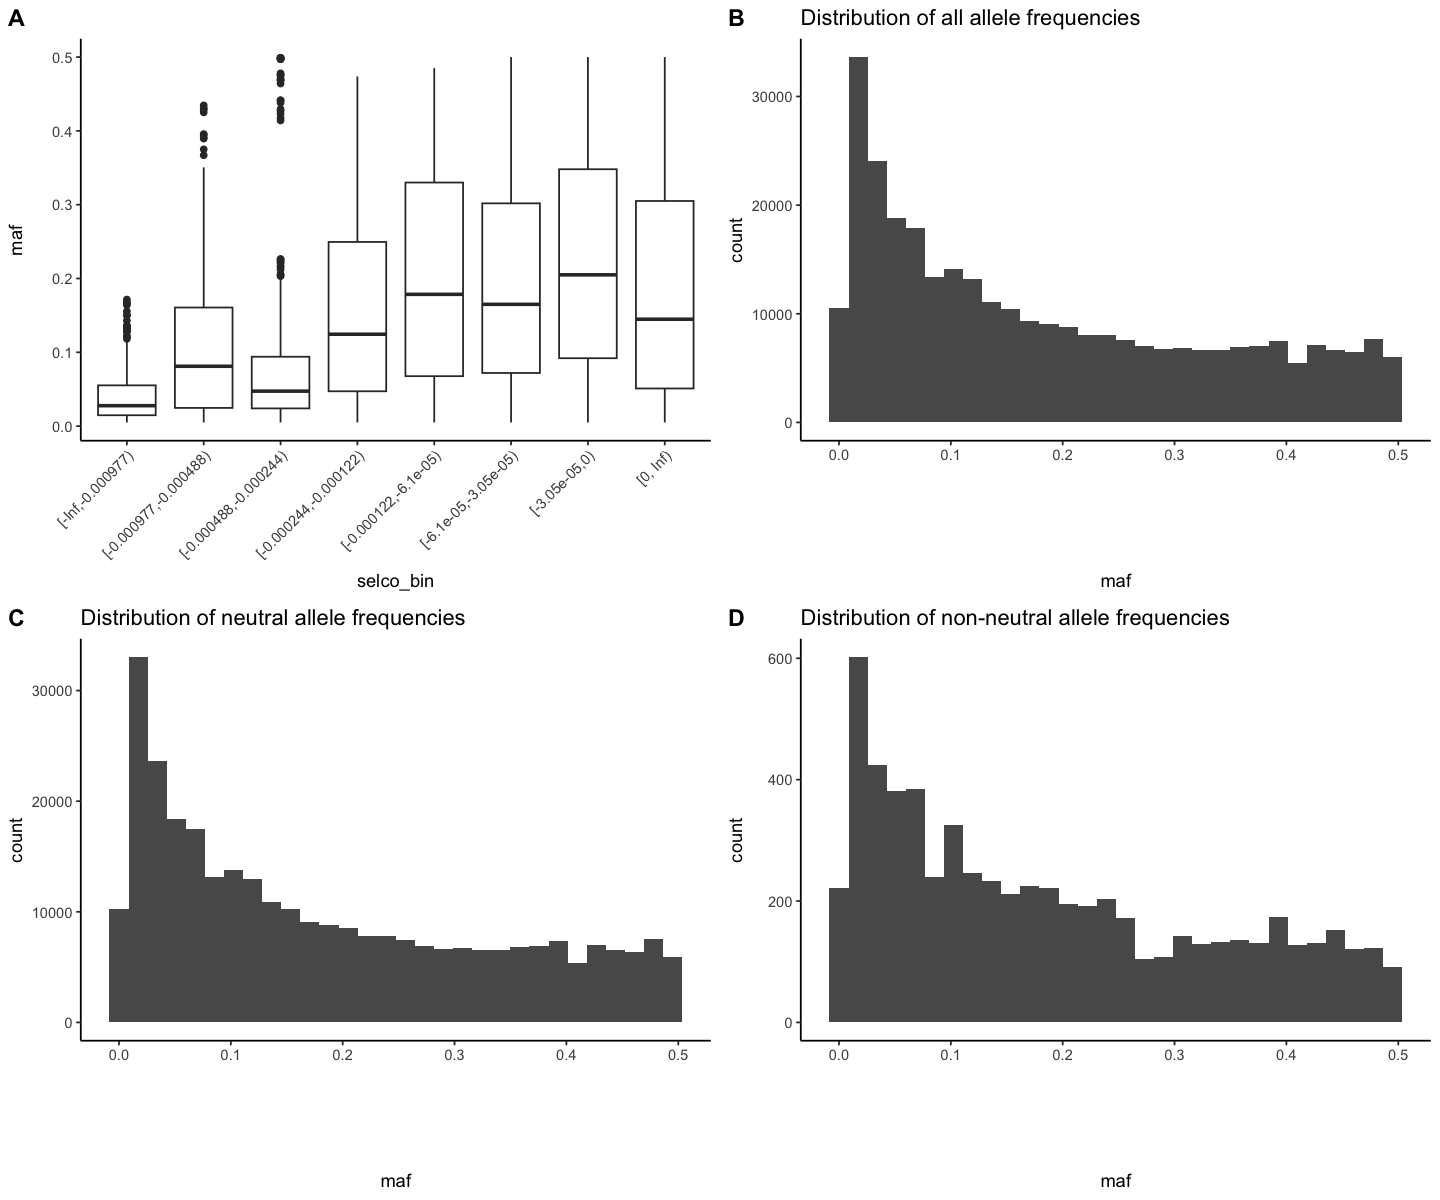

In [29]:
plot_selco_af(simE, min_maf=0.005)

In [45]:
simA$enloc %>% select(-Signal, -CPIP_gwas_marginal, -min_snp_pos_gwas, -correct, -position.y) %>% head()

gtex,gwas,Num_SNP,CPIP_qtl,CPIP_gwas_qtl_prior,RCP,LCP,gwas_p,min_snp_pos_gtex,gtex_p,⋯,gwas_selco,gwas_Vs,gwas_beta,selco_bin,maf_bin,dist_true_gwas_gtex,dist_lead_gwas_gtex,sim,gtex_category,species
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
tr512043,tr512043,1,1.0000,1.0000,1.0000,1.0000,0.00000e+00,512043,0.00000e+00,⋯,-0.0334972031,2.267683e-03,-6.4057844,"[-Inf,-0.000977)","(0.05,0.1]",0,29663,A1,gtex,human
tr524925,tr524925,1,1.0000,1.0000,1.0000,1.0000,0.00000e+00,524925,6.82203e-148,⋯,-0.0058597284,2.177589e-04,2.6792102,"[-Inf,-0.000977)","(0,0.05]",0,32314,A1,gtex,human
tr531618,tr531618,2,1.0000,1.0000,1.0010,1.0010,0.00000e+00,530497,3.83507e-259,⋯,-0.0336633697,5.747384e-04,6.4216531,"[-Inf,-0.000977)","(0,0.05]",0,121822,A1,gtex,human
tr532048,tr532048,1,1.0000,1.0000,1.0000,1.0000,0.00000e+00,532048,4.66944e-186,⋯,-0.0128895296,3.359529e-04,-3.9736222,"[-Inf,-0.000977)","(0,0.05]",0,3668,A1,gtex,human
tr536488,tr536488,27,0.9997,0.9994,1.0270,1.0340,4.88558e-184,536869,9.18733e-26,⋯,-0.0004294155,2.881813e-05,0.7252820,"[-0.000488,-0.000244)","(0.05,0.1]",0,381,A1,gtex,human
tr551932,tr551932,17,0.5373,0.9998,0.9664,0.9824,3.14780e-40,535745,1.50077e-06,⋯,-0.0002062670,4.518115e-06,0.5026699,"[-0.000244,-0.000122)","(0,0.05]",0,16187,A1,gtex,human


In [69]:
simA$vars %>% filter(selco < 0, beta != 0, type == 'gwas') %>% nrow()
simE$vars %>% filter(selco < 0, beta != 0, type == 'gwas') %>% nrow()

mA = simA$vars %>% filter(selco < 0, beta != 0, type == 'gwas') %>% pull(selco) %>% median()
mE = simE$vars %>% filter(selco < 0, beta != 0, type == 'gwas') %>% pull(selco) %>% median()
mA / mE

[1] 4871

[1] 1244

[1] 3.599267

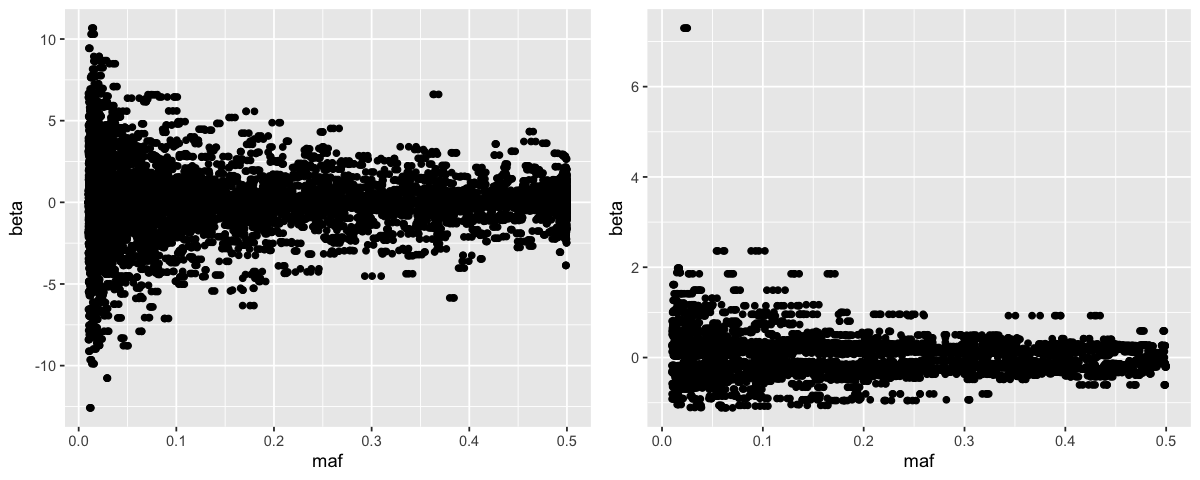

Warning message:
“Removed 467 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_density()`).”


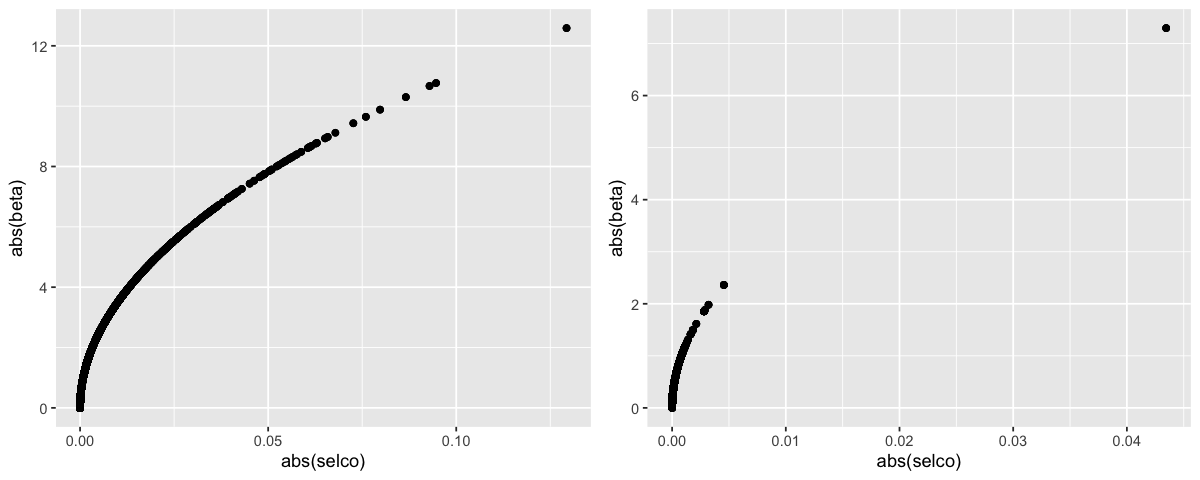

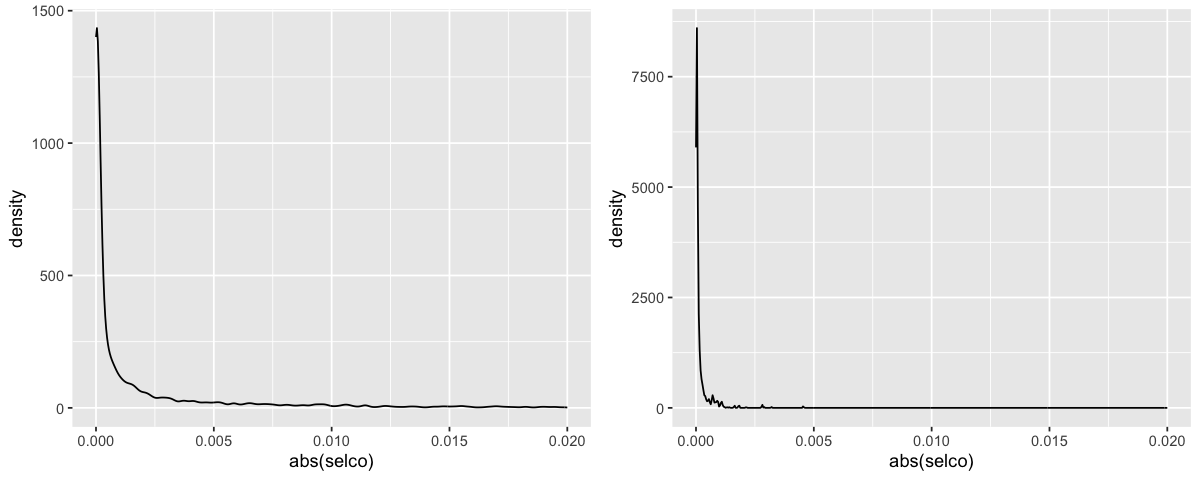

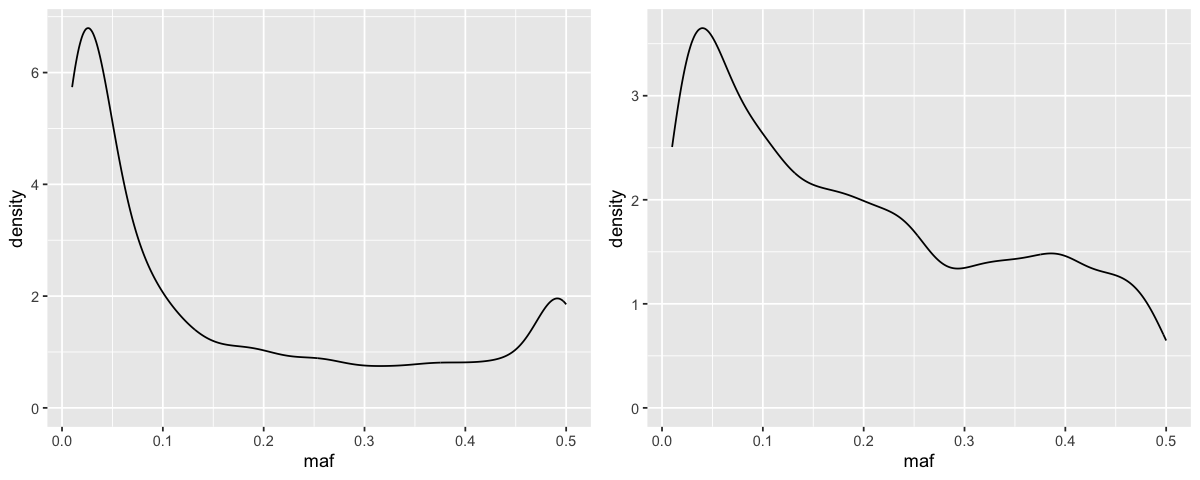

In [65]:
ctf = 0.01
fig_size(10, 4)
plot_grid(
simA$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=maf, y=beta)) + geom_point(),
simE$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=maf, y=beta)) + geom_point()
)

plot_grid(
simA$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=abs(selco), y=abs(beta))) + geom_point(),
simE$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=abs(selco), y=abs(beta))) + geom_point()
)

plot_grid(
simA$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=abs(selco))) + geom_density() + xlim(0, 0.02),
simE$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=abs(selco))) + geom_density() + xlim(0, 0.02)
)

plot_grid(
simA$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=maf)) + geom_density(),
simE$vars %>% filter(selco < 0, beta != 0, maf >= ctf) %>% ggplot(aes(x=maf)) + geom_density()
)

In [76]:
simA$traits %>% filter(type == 'gwas') %>% nrow()
simE$traits %>% filter(type == 'gwas') %>% nrow()

[1] 4878

[1] 1278

In [49]:
simA$vars %>% filter(type == 'gwas', beta != 0) %>% mutate(tmp = abs(beta)) %>% pull(tmp) %>% median()

[1] 1.523516

In [43]:
simA$enloc %>% select(-Signal, -CPIP_gwas_marginal, -min_snp_pos_gwas, -correct, -position.y) %>% head()

gtex,gwas,Num_SNP,CPIP_qtl,CPIP_gwas_qtl_prior,RCP,LCP,gwas_p,min_snp_pos_gtex,gtex_p,⋯,gwas_selco,gwas_Vs,gwas_beta,selco_bin,maf_bin,dist_true_gwas_gtex,dist_lead_gwas_gtex,sim,gtex_category,species
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
tr528817,tr528817,3,0.9996,1.0000,0.9979,1.000,2.77599e-263,526992,1.36381e-27,⋯,-0.0013232273,3.581775e-05,-1.2731667,"[-Inf,-0.000977)","(0,0.05]",0,0,A,gtex,human
tr552420,tr552420,31,0.9990,0.9999,0.9527,1.001,9.41758e-58,549077,3.09724e-09,⋯,-0.0001840459,8.076668e-06,-0.4748223,"[-0.000244,-0.000122)","(0,0.05]",0,3552,A,gtex,human
tr567738,tr565958,24,0.9999,1.0000,0.9615,1.000,4.20088e-81,568156,1.03596e-205,⋯,-0.0001212399,1.548989e-05,0.3853815,"[-0.000122,-6.1e-05)","(0.15,0.2]",1780,2033,A,gtex,human
tr567738,tr567829,24,0.9999,1.0000,0.9615,1.000,0.00000e+00,568156,1.03596e-205,⋯,-0.0027735867,3.536323e-04,-1.8432698,"[-Inf,-0.000977)","(0.1,0.15]",91,21716,A,gtex,human
tr567829,tr565958,22,0.9994,1.0000,0.9567,1.000,4.20088e-81,566123,1.43950e-170,⋯,-0.0001212399,1.548989e-05,0.3853815,"[-0.000122,-6.1e-05)","(0.15,0.2]",1871,0,A,gtex,human
tr574010,tr574010,1,0.9990,1.0000,1.0000,1.000,0.00000e+00,574010,1.64152e-154,⋯,-0.0071543418,2.884764e-04,2.9604170,"[-Inf,-0.000977)","(0,0.05]",0,22665,A,gtex,human


[1] 500
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   450     8    39     3
[1] 301
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1     2     0   190   109


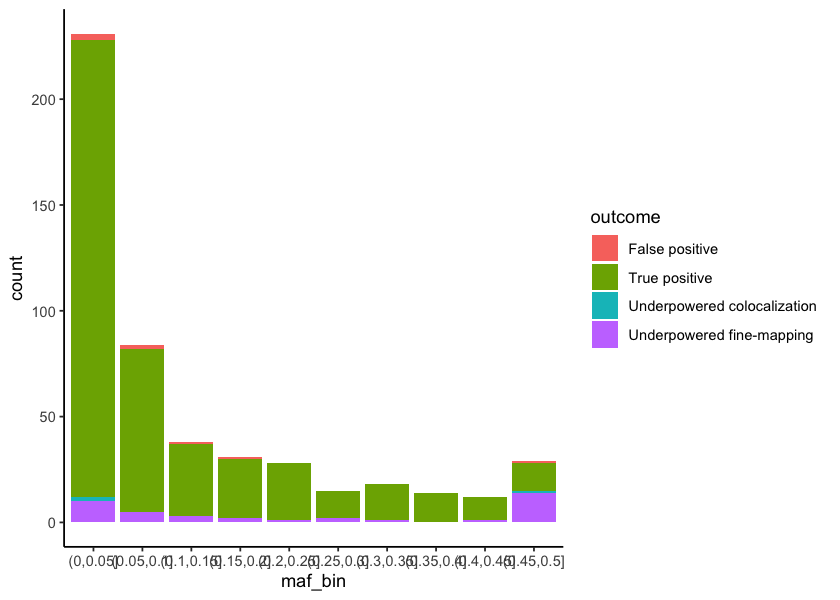

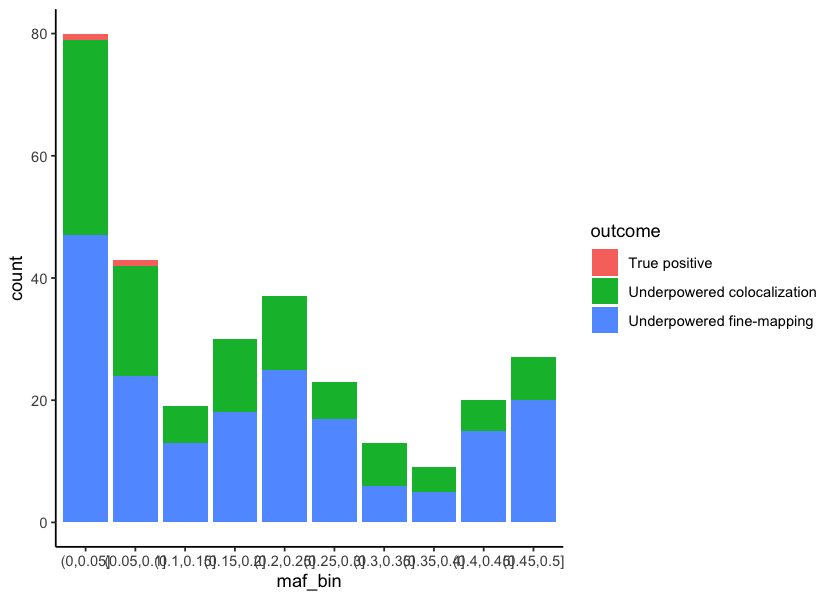

In [51]:
plot_enloc_outcomes(simA, p_cutoff=1, rcp_cutoff=0.5)
plot_enloc_outcomes(simE, p_cutoff=1, rcp_cutoff=0.5)

[1] 500
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   440     8    39    13
[1] 500
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   396     6    62    36


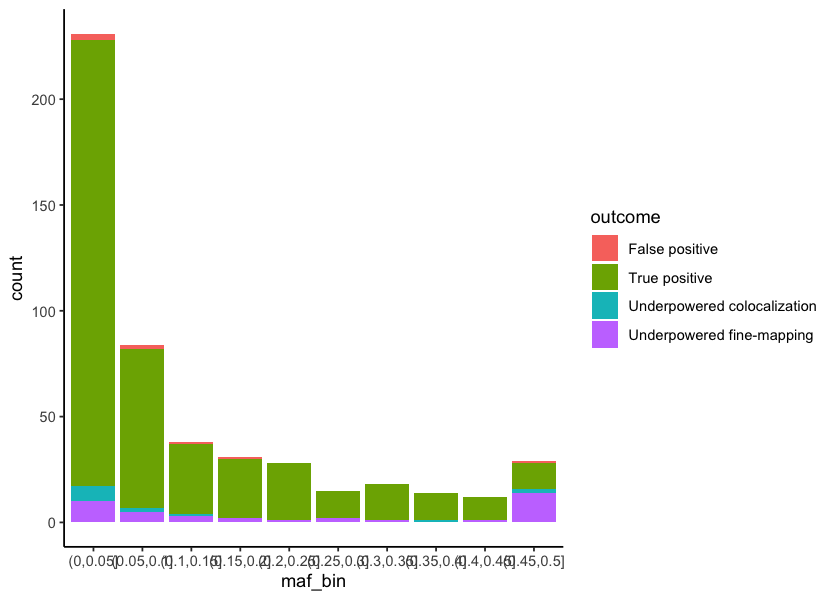

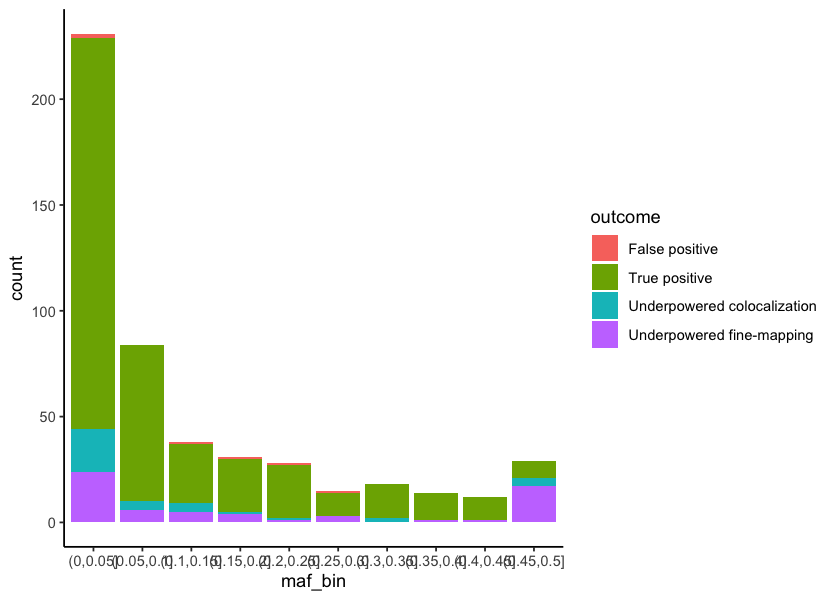

In [45]:
plot_enloc_outcomes(simA, p_cutoff=1, rcp_cutoff=0.9)
plot_enloc_outcomes(simA, p_cutoff=1, gtex_cat='gtex_smaller', rcp_cutoff=0.9)

[1] 4878
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1  2473   198  2017   190
[1] 1278
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   241    68   508   461


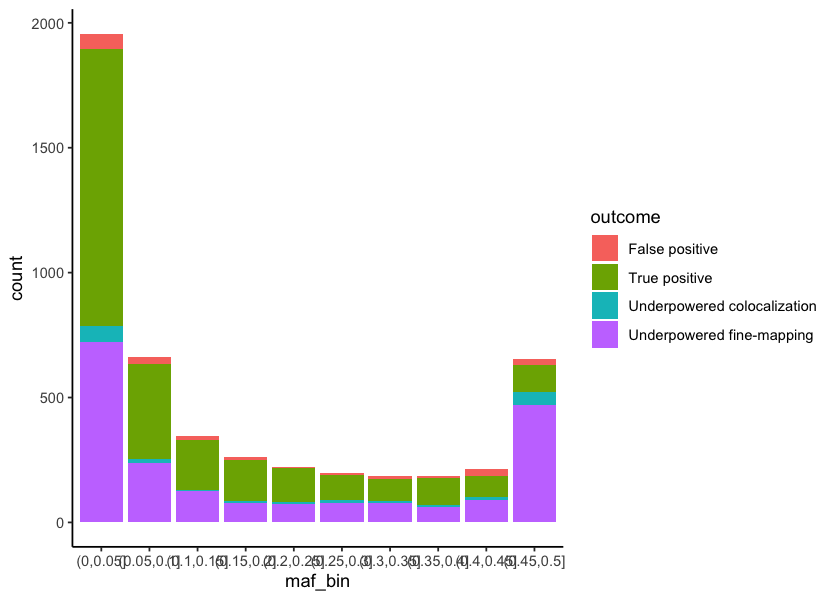

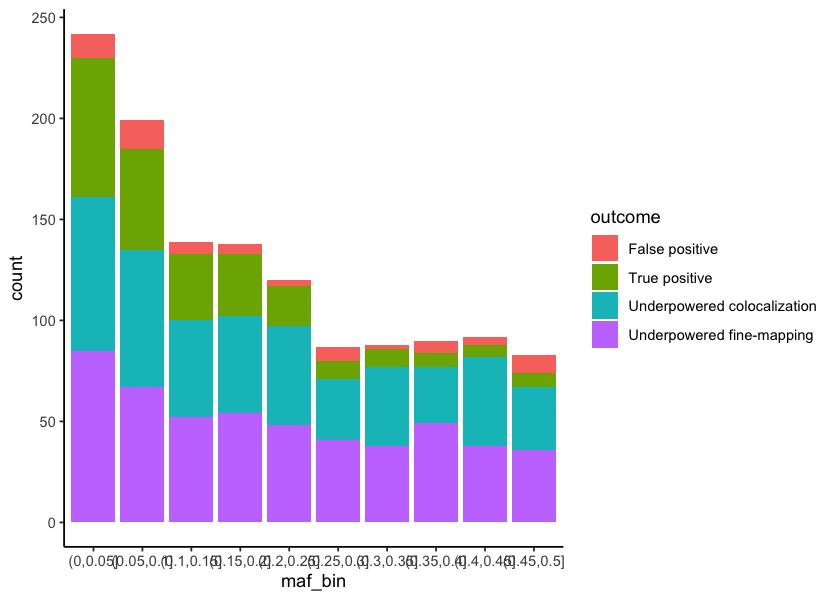

In [42]:
plot_enloc_outcomes(simA, p_cutoff=1)
plot_enloc_outcomes(simE, p_cutoff=1)

In [ ]:
plot_enloc_outcomes(simE, gtex_cat='gtex_smaller', p_cutoff=1)

[1] 1231
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   205    69   506   451
[1] 1231
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   105    41   555   530


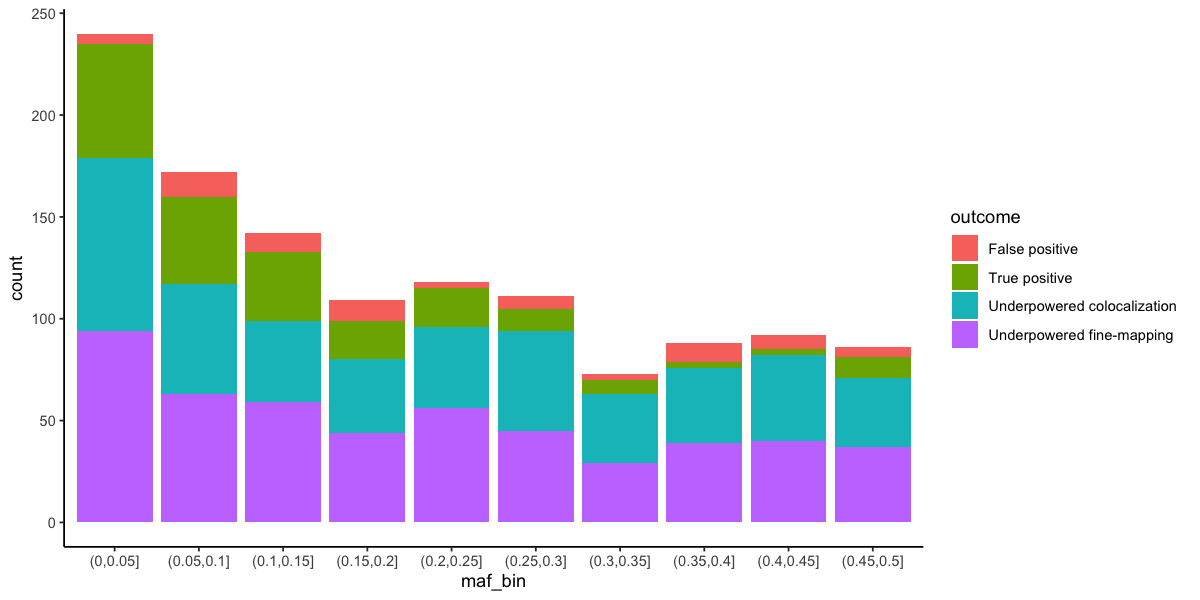

[1] 1231
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    24    10   622   575


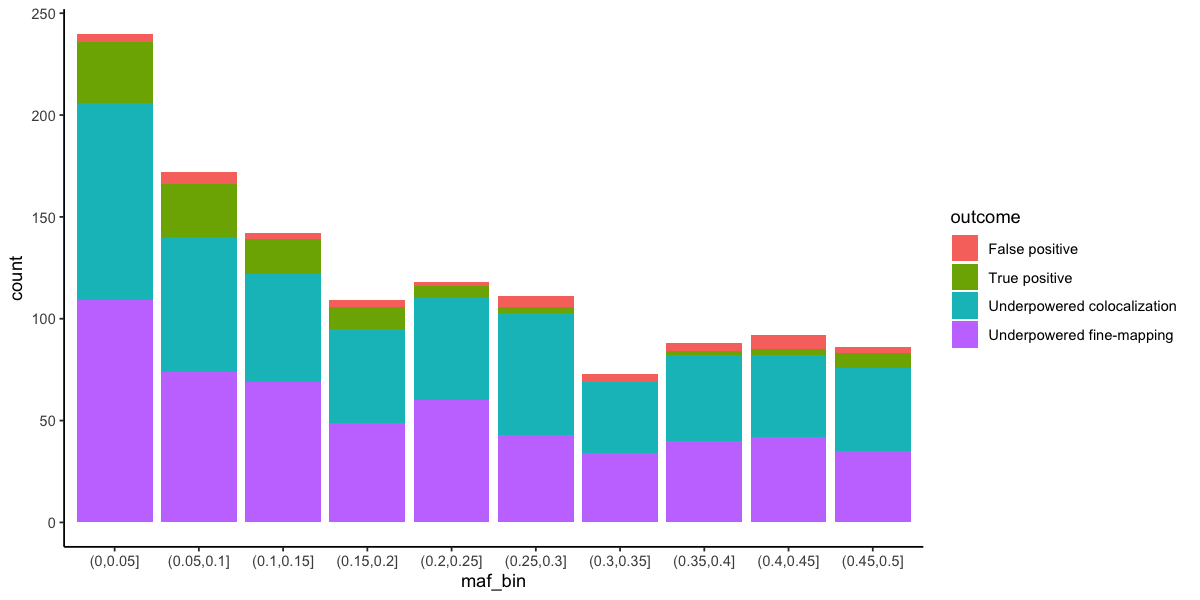

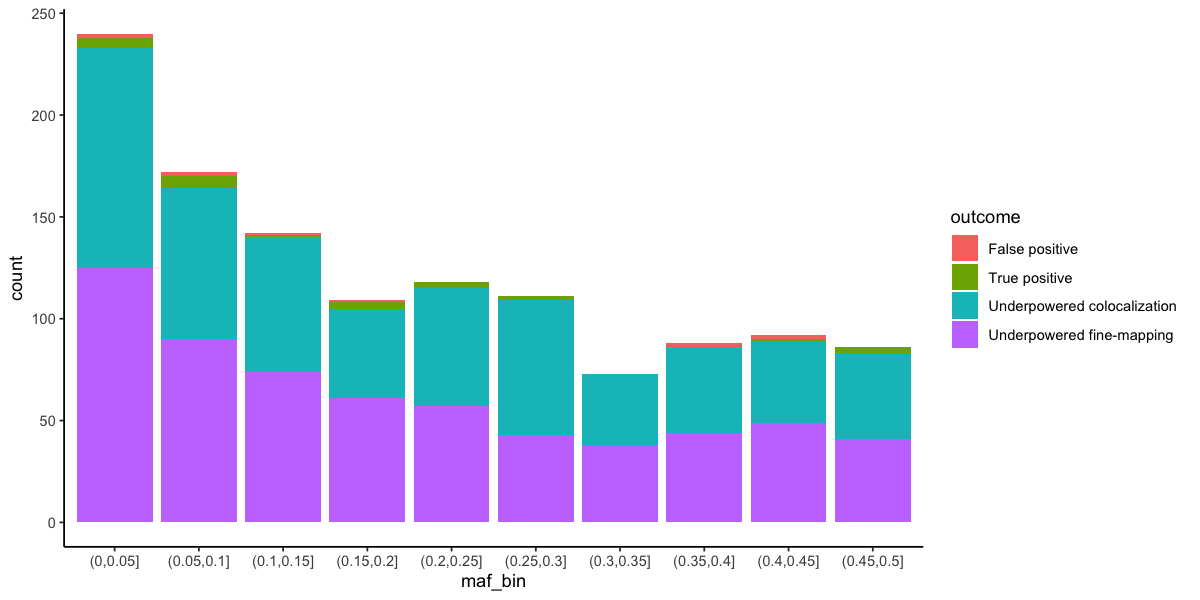

In [519]:
plot_enloc_outcomes(simF, p_cutoff=1)
plot_enloc_outcomes(simF, gtex_cat='gtex_smaller', p_cutoff=1)
plot_enloc_outcomes(simF, gtex_cat='gtex_smallest', p_cutoff=1)

[1] 1231
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   205    69   506   451
[1] 50
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1     8     5    20    17


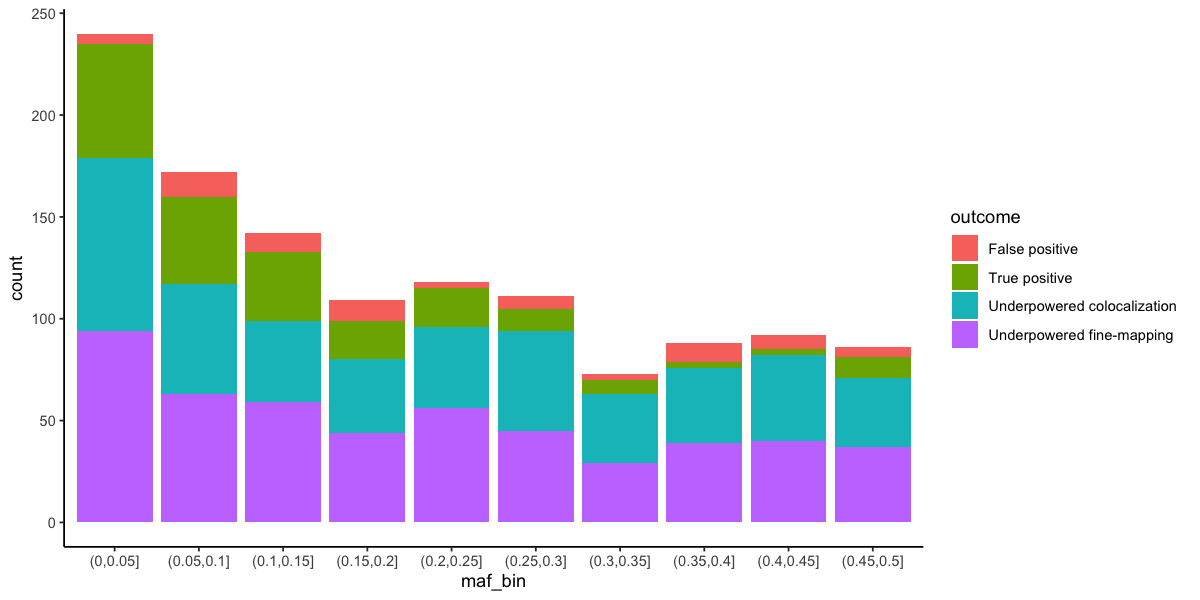

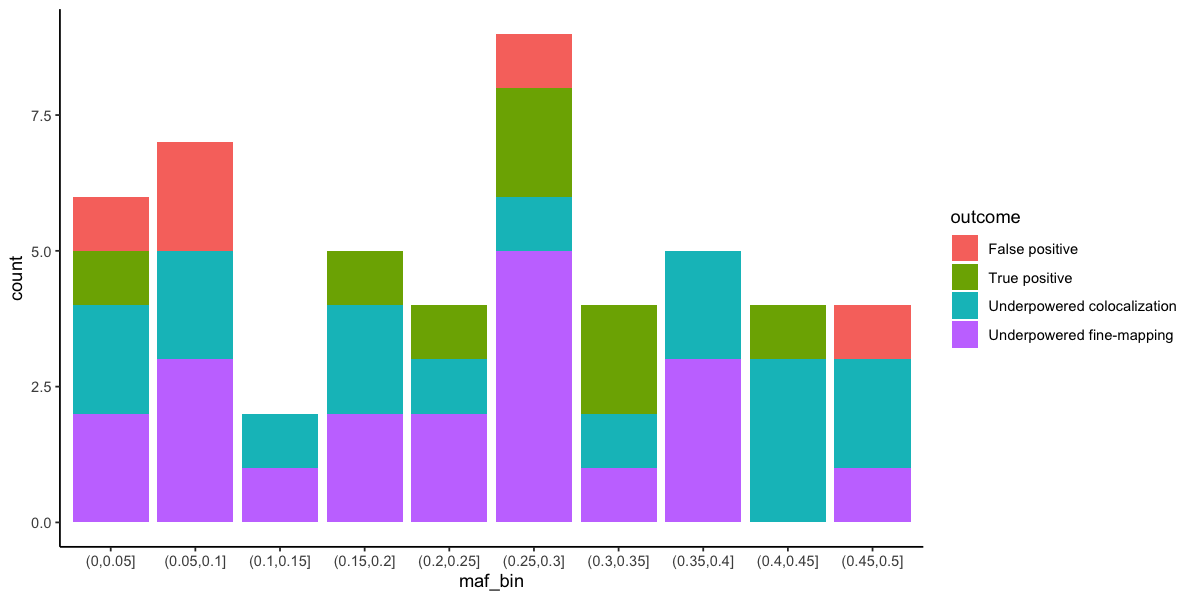

In [522]:
plot_enloc_outcomes(simF, p_cutoff=1, m4=T)

[1] 1282


tp,fp,ufm,uc
<int>,<int>,<int>,<int>
241,52,297,300


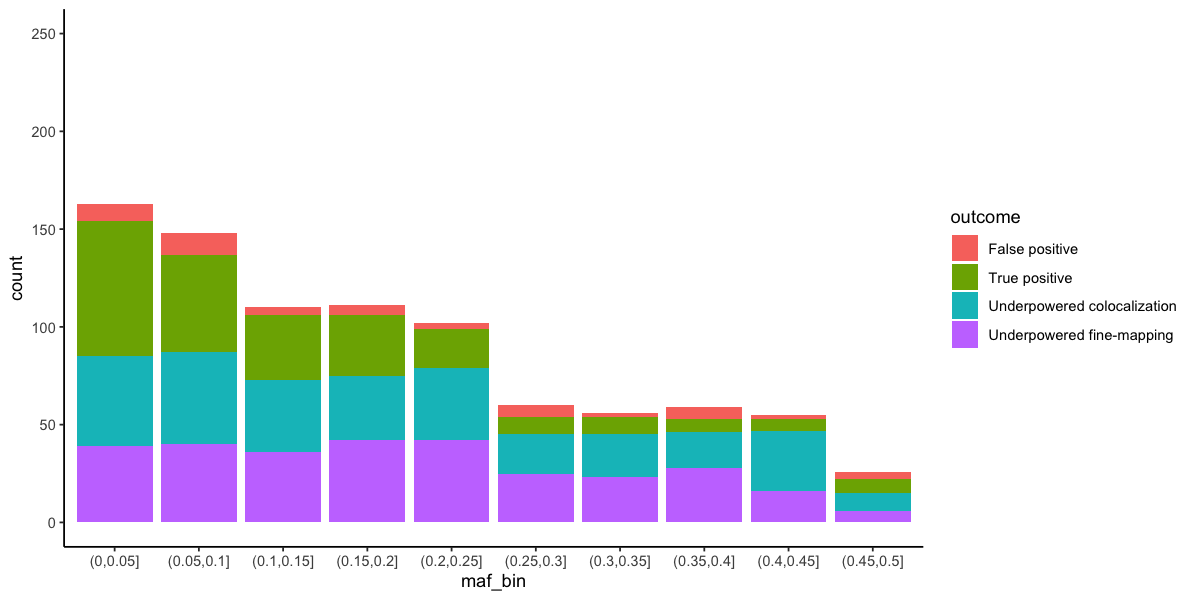

In [363]:
# GWAS powered
tmp = eenloc %>% 
    arrange(desc(is.na(correct)), desc(correct), desc(is.na(RCP)), desc(RCP)) %>% 
    group_by(gwas, sim) %>%
    slice(1) %>%
    ungroup() %>% 
    mutate(RCP = ifelse(is.na(RCP), 0, RCP)) %>%
    mutate(outcome = ifelse(is.na(correct), 'Underpowered fine-mapping', ifelse(RCP <= 0.5, 'Underpowered colocalization', ifelse(correct, 'True positive', 'False positive')))) %>% 
    filter(!is.na(maf_bin), gwas_p < 5e-8)

tot = length(unique(paste(eenloc$gwas, eenloc$sim)))
print(tot)
tmp %>%
    summarize(tp = sum(outcome == 'True positive'), fp = sum(outcome == 'False positive'), ufm = sum(outcome == 'Underpowered fine-mapping'), uc = sum(outcome == 'Underpowered colocalization'))
    # summarize(tp = sum(outcome == 'True positive')/tot, fp = sum(outcome == 'False positive')/tot, ufm = sum(outcome == 'Underpowered fine-mapping')/tot, uc = sum(outcome == 'Underpowered colocalization')/tot)

tmp %>%
ggplot(aes(x=maf_bin, fill=outcome)) + geom_bar(stat='count') + theme_classic() + ylim(0, 250)

[1] 1282


tp,fp,ufm,uc
<int>,<int>,<int>,<int>
262,96,297,235


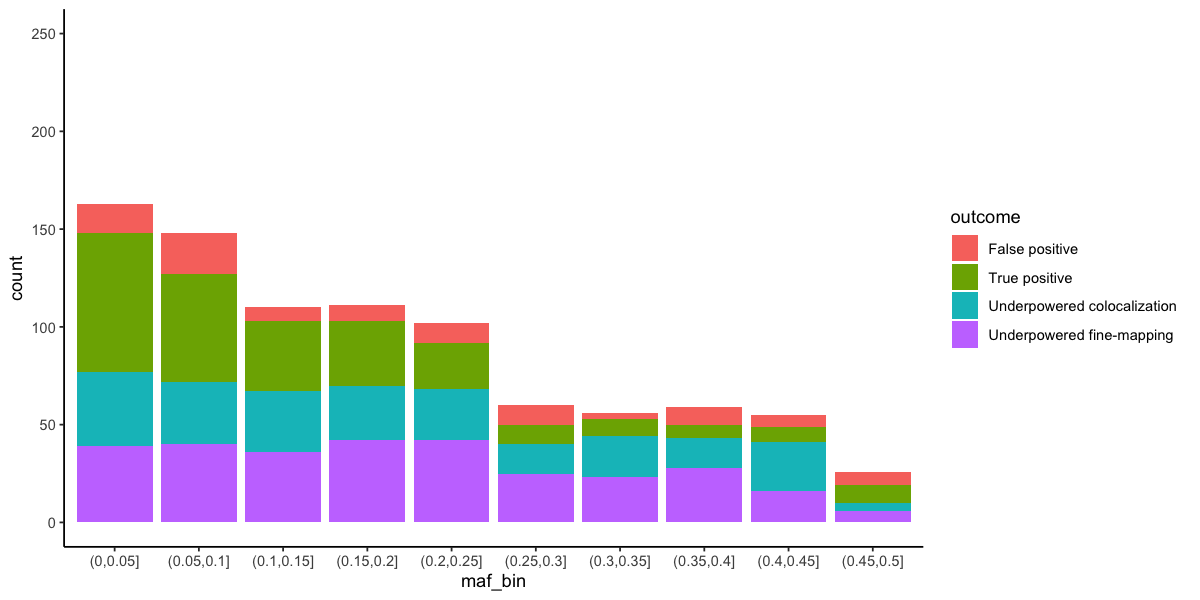

In [354]:
# GWAS powered
tmp = eenloc %>% 
    arrange(desc(is.na(correct)), desc(correct), desc(is.na(RCP)), desc(RCP)) %>% 
    group_by(gwas, sim) %>%
    slice(1) %>%
    ungroup() %>% 
    mutate(RCP = ifelse(is.na(RCP), 0, RCP)) %>%
    mutate(outcome = ifelse(is.na(correct), 'Underpowered fine-mapping', ifelse(RCP <= 0.2, 'Underpowered colocalization', ifelse(correct, 'True positive', 'False positive')))) %>% 
    filter(!is.na(maf_bin), gwas_p < 5e-8)

tot = length(unique(paste(eenloc$gwas, eenloc$sim)))
print(tot)
tmp %>%
    summarize(tp = sum(outcome == 'True positive'), fp = sum(outcome == 'False positive'), ufm = sum(outcome == 'Underpowered fine-mapping'), uc = sum(outcome == 'Underpowered colocalization'))
    # summarize(tp = sum(outcome == 'True positive')/tot, fp = sum(outcome == 'False positive')/tot, ufm = sum(outcome == 'Underpowered fine-mapping')/tot, uc = sum(outcome == 'Underpowered colocalization')/tot)

tmp %>%
ggplot(aes(x=maf_bin, fill=outcome)) + geom_bar(stat='count') + theme_classic() + ylim(0, 250)

# Set 2: GWAS 5x, GTEx 20x, causative cutoff 0.001, fine-mapping and glm cutoff 0.01, r2 cutoff 0.75

In [8]:
Arare = get_dfs('A', ddir_base = '/Users/noah/colocalization_humans_cattle_pigs/simulation_data/cmaf001_fm01_g5t20_2Mb/', replicates=5)

[1] "Error: no matching file"


ERROR: Error in read.table(get_regex_file(ddir, paste0(gtex_category, ".enloc.sig.out")), : 'file' must be a character string or connection
